# Unit 7: Convolutional Neural Networks and Transfer Learning

---

## Overview

This notebook teaches **CNNs** and **transfer learning** for computer vision. You will build and train convolutional networks, understand padding/stride, explore popular architectures (LeNet, VGG, ResNet), apply transfer learning, run a full image-classification project, and visualize what CNNs learn.

**Prerequisites:** Basic Python, NumPy, and neural networks (e.g. Unit 6).  
**Estimated time:** ~11 hours  
**Learning outcomes:** Design CNNs, use padding/stride, compare architectures, fine-tune pre-trained models, run an end-to-end pipeline, interpret CNN decisions.

---


![CNN](https://media.geeksforgeeks.org/wp-content/uploads/20250207123959732912/Working-of-CNN_.webp)

### Why CNNs for vision? (Simple explanation)

- **Parameter sharing:** Imagine one small "stencil" (e.g. 3×3) that you slide across the whole image. The same stencil is reused everywhere—so you need only 9 weights per filter, not millions. A fully connected layer would need a separate weight for every pixel.

- **Translation invariance:** A filter that detects "vertical edge" works the same whether the edge is at the top or bottom of the image. The network learns patterns that are useful anywhere.

- **Local connectivity:** Each neuron only looks at a small patch (e.g. 3×3) of the image. This matches how images work: nearby pixels are related (edges, textures); distant pixels are often independent.

---

### Install dependencies

Run in terminal if needed:
```bash
pip install torch torchvision matplotlib numpy seaborn scikit-learn ipywidgets
```
Optional: `pip install torchcam captum` for visualization (7.6).

---

### Significance: Why CNNs dominate vision

> **Parameter sharing:** A single 3×3 filter has 9 weights (per channel); it is applied at every position. A fully connected layer from 224×224×3 to 64 would need 224×224×3×64 ≈ 9.6M weights for one layer. Convolution uses order of thousands and reuses the same filter—hence efficiency and translation invariance.
>
> **Real-world:** Face detection, medical imaging, self-driving (lane/object detection), and most image classification benchmarks (ImageNet, etc.) use CNNs.

### Glossary (quick reference — explained simply)

- **Conv2d (Convolution 2D):** A layer that slides a small "filter" (e.g. 3×3) across the image. At each position it multiplies the filter with the image patch and sums the result. Think of it as a pattern detector that learns edges, textures, etc. Parameters: `in_channels` (input colors/channels), `out_channels` (how many filters), `kernel_size` (filter size), `stride`, `padding`.

- **MaxPool2d / AvgPool2d:** Shrink the image by replacing each small window (e.g. 2×2) with one value. **MaxPool** = take the maximum (keeps strongest signal). **AvgPool** = take the average (smoother). Used to reduce size and make the model less sensitive to small shifts.

- **Receptive field:** The patch of the input image that "feeds into" one output pixel. Early layers see small patches (e.g. 3×3); deep layers see larger regions.

- **Transfer learning:** Start with a model already trained on millions of images (e.g. ImageNet). Reuse its learned features and only train a new "head" for your task. Saves time and works with less data.

- **Freezing:** Turn off training for some layers (`requires_grad=False`). The frozen layers keep their pre-trained weights; only the unfrozen parts (e.g. classifier) are updated.

- **Grad-CAM:** A heatmap showing *where* in the image the model looked when making a prediction. Red = high importance, blue = low.

In [1]:
# Imports and device setup — works on Apple M chips, Windows (NVIDIA GPU), and CPU
%matplotlib inline
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import time
import random
import platform

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(42)

# Cross-platform device selection: Apple M (MPS) > NVIDIA GPU (CUDA) > CPU
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda"), f"NVIDIA GPU: {torch.cuda.get_device_name(0)}"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps"), "Apple M1/M2/M3/M4 (MPS)"
    return torch.device("cpu"), "CPU"

device, device_name = get_device()
print(f"Platform: {platform.system()} ({platform.machine()})")
print(f"Using device: {device} ({device_name})")

# Safe num_workers for DataLoader: 0 avoids multiprocessing issues on Windows and some Mac setups
NUM_WORKERS = 0

# If you see MPS errors on Apple M (e.g. "not implemented"), force CPU: device = torch.device("cpu")

Platform: Darwin (arm64)
Using device: mps (Apple M1/M2/M3/M4 (MPS))


### Basic terms (beginner-friendly)

- **Kernel / Filter:** A small matrix (e.g. 3×3) of numbers. The CNN learns these numbers during training. Each kernel detects one type of pattern (edge, corner, texture).

- **Feature map:** The output of a convolution. If you have 32 kernels, you get 32 feature maps (one per kernel). Each "pixel" in a feature map is the result of one convolution at that position.

- **Stride:** How many pixels the kernel moves each step. Stride 1 = move 1 pixel; stride 2 = move 2 pixels (output is half the size).

- **Padding:** Extra pixels added around the image (usually zeros). Used to keep the output size the same as the input when using stride 1.

- **Flatten:** Reshape a 3D tensor (batch, channels, height, width) into 2D (batch, channels×height×width) so it can go into a fully connected layer.

---

<a id='71'></a>

# 7.1 CNN Architecture: Convolution, Pooling, Fully Connected Layers

**Time:** 3–4 hrs

A CNN typically has: **Convolution layers** (learn local features), **Pooling layers** (reduce size, add invariance), **Fully connected layers** (classifier).

---

## Convolution (2D)

**Intuition:** Imagine sliding a small "stencil" (the **kernel** or **filter**) across the image. At each position you multiply the stencil with the patch underneath and sum the result—that gives one number in the **output feature map**. One kernel produces **one channel** of the output; 64 kernels produce 64 channels. The kernel is **learned** during training, so the network discovers useful patterns (edges, corners, textures) by itself.

**Formula.** Discrete 2D convolution of input $f$ with kernel $g$:

$$ (f * g)(i,j) = \sum_m \sum_n f(m,n) \, g(i-m, j-n) $$

In code we usually implement this as: at output position $(i,j)$, take the patch of the input centered there (same size as the kernel), do **element-wise product** with the kernel, then **sum** → one scalar. So each output pixel is a **dot product** between a local patch and the kernel. In deep learning the kernel is **learned** (the weights of the conv layer), not hand-designed.

**Why "convolution"?** In math, convolution measures overlap between two functions as one is shifted. Here we "shift" the kernel to every position—hence the name.

### Deep dive: Convolution by hand (numeric example)

Suppose we have a **4×4** input and a **2×2** kernel. We slide the kernel so it stays fully inside the image (no padding). How many valid positions? In the height dimension we can place the kernel at starting rows 0, 1, 2 (so 3 positions); same for width → **3×3 = 9** positions. So output size is (4−2+1)×(4−2+1) = **3×3**. At each of the 9 positions we compute the sum of element-wise products between the 2×2 patch and the 2×2 kernel. At each position we compute the sum of element-wise products between the 2×2 patch and the 2×2 kernel. This is exactly what the code does in the next cell—run it and compare with a tiny array to build intuition.

In [2]:
# Step 1: Define the convolution function (we'll use it in the examples below)
def conv2d_numpy(X, K):
    """Manual 2D convolution — no padding, stride 1.
    X: (H, W) input, K: (kH, kW) kernel. Output: (H - kH + 1, W - kW + 1).
    At each position we multiply the patch with the kernel and sum."""
    H, W = X.shape
    kH, kW = K.shape
    out_h = H - kH + 1
    out_w = W - kW + 1
    Y = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            patch = X[i:i+kH, j:j+kW]
            Y[i, j] = np.sum(patch * K)
    return Y

# Step 2: Convolution by hand — 4×4 input, 2×2 kernel → 3×3 output
X_small = np.array([[1., 0., 1., 0.], [0., 1., 1., 0.], [1., 1., 0., 1.], [0., 0., 1., 1.]])
K_small = np.array([[1., -1.], [0., 1.]])
Y_small = conv2d_numpy(X_small, K_small)
print("Input (4×4):\n", X_small)
print("Kernel (2×2):\n", K_small)
print("Output (3×3):\n", Y_small)
print("Top-left output = sum of X[0:2,0:2]*K =", np.sum(X_small[0:2, 0:2] * K_small))

Input (4×4):
 [[1. 0. 1. 0.]
 [0. 1. 1. 0.]
 [1. 1. 0. 1.]
 [0. 0. 1. 1.]]
Kernel (2×2):
 [[ 1. -1.]
 [ 0.  1.]]
Output (3×3):
 [[2. 0. 1.]
 [0. 0. 2.]
 [0. 2. 0.]]
Top-left output = sum of X[0:2,0:2]*K = 2.0


In [3]:
# Practical example: Edge detector on random 8×8 image
# The Sobel-like kernel [[-1,0,1],[-2,0,2],[-1,0,1]] detects vertical edges
np.random.seed(42)
img = np.random.randn(8, 8)
kernel = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])  # vertical edge
out = conv2d_numpy(img, kernel)
print("Input shape:", img.shape)
print("Kernel shape:", kernel.shape)
print("Output shape:", out.shape)

Input shape: (8, 8)
Kernel shape: (3, 3)
Output shape: (6, 6)


In [4]:
# PyTorch Conv2d on a sample image (single channel)
conv = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=0)
x = torch.randn(1, 1, 28, 28)  # (batch, channels, H, W)
y = conv(x)
print("Input:", x.shape)
print("Conv2d(1, 4, k=3):", y.shape)
print("Parameters:", sum(p.numel() for p in conv.parameters()))

Input: torch.Size([1, 1, 28, 28])
Conv2d(1, 4, k=3): torch.Size([1, 4, 26, 26])
Parameters: 40


**How many parameters in a conv layer?** `Conv2d(in_channels, out_channels, kernel_size)` has **weights**: `in_channels × out_channels × k × k`, and **biases**: `out_channels` (one per output channel). Example: Conv2d(1, 4, 3) → 1×4×3×3 + 4 = 40 parameters. The same 40 parameters are reused at every spatial position (parameter sharing)—unlike a fully connected layer, which would need a separate weight for each input pixel.

## Pooling

**What it does:** Pooling divides the feature map into small windows (e.g. 2×2) and replaces each with one value, so **spatial size shrinks** (e.g. 28×28 → 14×14).  

- **MaxPool2d:** Take the **maximum** in each window—keeps the strongest activation and adds **translation invariance** (small shifts often give the same max).  
- **AvgPool2d:** Take the **average**; smoother, sometimes used before the classifier (e.g. Global Average Pooling).  

**Why invariance?** Small shifts in the input can yield the same pooled value, so the network cares less about exact position (helpful for recognition).

In [5]:
x = torch.randn(1, 4, 26, 26)
mp = nn.MaxPool2d(2, stride=2)
ap = nn.AvgPool2d(2, stride=2)
print("Input:", x.shape)
print("After MaxPool2d(2):", mp(x).shape)
print("After AvgPool2d(2):", ap(x).shape)

Input: torch.Size([1, 4, 26, 26])
After MaxPool2d(2): torch.Size([1, 4, 13, 13])
After AvgPool2d(2): torch.Size([1, 4, 13, 13])


### Significance

| Concept | Role |
|--------|------|
| **Convolution** | Learns local patterns (edges → textures → parts). Same filter reused → parameter sharing. |
| **Pooling** | Downsamples, reduces computation, adds invariance to small shifts. |
| **FC at end** | Combines high-level features into class scores. |

Efficiency: A single 3×3 conv with 64 filters has far fewer parameters than a fully connected layer from 224×224×3 to 64.

---

### Why ReLU after convolution?

Convolution is linear; real-world patterns are **non-linear**. **ReLU** adds non-linearity so the network can approximate complex functions. It also avoids vanishing gradients (gradient is 1 for positive inputs) and is fast. Modern stacks often use **Conv → BatchNorm → ReLU**.

### Feature hierarchy: what do layers learn?

**Early layers** tend to learn edges, corners, simple textures. **Middle layers** learn textures and part-like patterns. **Deep layers** respond to high-level structures (object parts). The **FC head** maps these to class scores. So the network builds a hierarchy (local → global, simple → complex)—which is why transfer learning works: early layers are generic; only the top is task-specific.

## Full CNN stack: Conv → Pool → FC → Output

Example: Conv → ReLU → Pool → Flatten → FC → Output.

In [6]:
class TinyCNN(nn.Module):
    """A small CNN for MNIST (28×28 grayscale). Structure: Conv → Pool → Conv → Pool → FC → Output."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)   # 1 channel in, 16 filters out; padding=1 keeps size
        self.pool = nn.MaxPool2d(2, 2)                # 2×2 windows, stride 2 → halves each dimension
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)  # 16 channels in, 32 out
        self.fc1 = nn.Linear(32 * 7 * 7, 128)        # After 2 pools: 28→14→7, so 7×7 spatial, 128 nodes (Hidden Layer / fc1)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # (B,16,14,14)
        x = self.pool(F.relu(self.conv2(x)))   # (B,32,7,7)
        x = x.view(x.size(0), -1)   # Flatten: (B, 32*7*7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = TinyCNN(10)
print(model)
print("Total params:", sum(p.numel() for p in model.parameters()))

TinyCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Total params: 206922


### Practice questions (7.1)

1. **Output shape:** Input (batch=4, C=3, H=32, W=32). Conv2d(3, 64, kernel_size=5, stride=1, padding=0). What is the output spatial size?  
   <details><summary>Solution</summary>  
   H_out = 32 - 5 + 1 = 28, W_out = 28. So (4, 64, 28, 28).  
   </details>

2. **Parameters:** Conv2d(in=16, out=32, kernel_size=3). How many parameters?  
   <details><summary>Solution</summary>  
   Weights: 16×32×3×3 = 4608, Biases: 32. Total = 4640.  
   </details>

3. After MaxPool2d(2,2), (batch, 64, 14, 14) → ?  
   <details><summary>Solution</summary>  
   (batch, 64, 7, 7).  
   </details>

### 1D convolution (from scratch)

For a 1D signal $x$ and kernel $w$, the convolution is $(x * w)(i) = \\sum_n x(n) \\, w(i-n)$. We slide the kernel and compute the dot product at each position.

In [7]:
# Manual 1D convolution (NumPy)
def conv1d_numpy(x, w):
    """x: (L,), w: (k,). Output length L - k + 1."""
    L, k = len(x), len(w)
    out = np.zeros(L - k + 1)
    for i in range(len(out)):
        out[i] = np.sum(x[i:i+k] * w)
    return out

x = np.array([1., 2., 3., 4., 5., 6., 7.])
w = np.array([0.5, -0.5])
print("1D conv output:", conv1d_numpy(x, w))

1D conv output: [-0.5 -0.5 -0.5 -0.5 -0.5 -0.5]


## Hands-on: Train tiny CNN on MNIST

In [8]:
# MNIST: 28×28 grayscale digits (0–9). Normalize with dataset mean/std for stable training.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])
train_set = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_set = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
# num_workers=0: safe on Windows and Apple M (avoids multiprocessing issues)
train_loader = DataLoader(train_set, batch_size=64, shuffle=True, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=NUM_WORKERS)
print("MNIST train:", len(train_set), "test:", len(test_set))

MNIST train: 60000 test: 10000


In [9]:
def train_epoch(model, loader, criterion, optimizer, device):
    """One training epoch: loop over batches, forward, loss, backward, update weights."""
    model.train()
    total_loss, correct, n = 0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)  # Move to GPU/MPS/CPU
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        n += len(y)
        correct += (out.argmax(1) == y).sum().item()
    return total_loss / len(loader), correct / n

def eval_model(model, loader, device):
    """Evaluate: no gradients, count correct predictions."""
    model.eval()
    correct, n = 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            correct += (out.argmax(1) == y).sum().item()
            n += len(y)
    return correct / n

model = TinyCNN(10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
for epoch in range(3):
    loss, acc = train_epoch(model, train_loader, criterion, optimizer, device)
    test_acc = eval_model(model, test_loader, device)
    print(f"Epoch {epoch+1}  Train loss: {loss:.4f}  Train acc: {acc:.4f}  Test acc: {test_acc:.4f}")
print("Done.")

Epoch 1  Train loss: 0.1626  Train acc: 0.9506  Test acc: 0.9819
Epoch 2  Train loss: 0.0507  Train acc: 0.9843  Test acc: 0.9871
Epoch 3  Train loss: 0.0346  Train acc: 0.9890  Test acc: 0.9861
Done.


---

<a id='72'></a>

# 7.2 Understanding Padding and Stride

**Time:** 1–2 hrs

**Output size** (one dimension):
$$ H_{\text{out}} = \left\lfloor \frac{H_{\text{in}} + 2p - k}{s} \right\rfloor + 1 $$
where $p$ = padding, $k$ = kernel size, $s$ = stride.

**Where the formula comes from:** We slide the kernel in steps of $s$. The padded length is $H_{\text{in}}+2p$; the kernel needs $k$ cells, so the last valid start index is $(H_{\text{in}}+2p)-k$. The number of start positions is $\lfloor ((H_{\text{in}}+2p)-k)/s \rfloor + 1$.

**Numeric example:** $H_{\text{in}}=5$, $k=3$, $s=1$, $p=0$ → start positions 0,1,2 → **3 outputs**. Formula: $\lfloor (5-3)/1 \rfloor + 1 = 3$. With $p=1$, length 7 → 5 start positions → **5 outputs** (same as input = "same" padding).

- **Valid:** no padding ($p=0$). Output shrinks.
- **Same:** for stride 1, $p=(k-1)/2$ gives $H_{\text{out}}=H_{\text{in}}$ (e.g. $k=3$ ⇒ $p=1$).

### Visual: Edge detector on a real image

The Sobel-like kernel we used (vertical edge) highlights vertical boundaries. Below we apply it to one MNIST digit to see the effect.

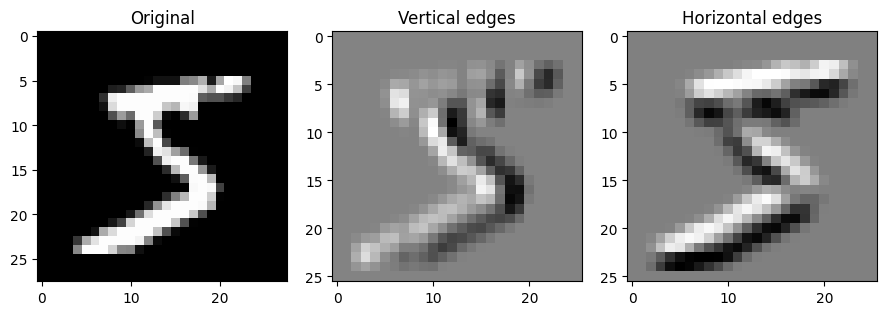

In [10]:
# Get one MNIST image and apply edge kernel
train_set_temp = datasets.MNIST("./data", train=True, download=True, transform=transforms.ToTensor())
img, _ = train_set_temp[0]
img_np = img.squeeze().numpy()
kernel_v = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]) # Sobel Edge Detector for vertical edges
edges = conv2d_numpy(img_np, kernel_v)
fig, ax = plt.subplots(1, 3, figsize=(9, 3))
ax[0].imshow(img_np, cmap='gray'); ax[0].set_title('Original')
ax[1].imshow(edges, cmap='gray'); ax[1].set_title('Vertical edges')
ax[2].imshow(conv2d_numpy(img_np, kernel_v.T), cmap='gray'); ax[2].set_title('Horizontal edges')
plt.tight_layout(); plt.show()

In [11]:
def out_size(H_in, k, s=1, p=0):
    return (H_in + 2*p - k) // s + 1

print("H_in=32, k=5, s=1, p=0:", out_size(32, 5, 1, 0))
print("H_in=32, k=3, s=1, p=1 (same):", out_size(32, 3, 1, 1))
print("H_in=32, k=3, s=2, p=1:", out_size(32, 3, 2, 1))

H_in=32, k=5, s=1, p=0: 28
H_in=32, k=3, s=1, p=1 (same): 32
H_in=32, k=3, s=2, p=1: 16


In [12]:
# Effect of padding and stride on feature map size
x = torch.randn(1, 1, 28, 28)
for p, s in [(0, 1), (1, 1), (0, 2)]:
    conv = nn.Conv2d(1, 4, 3, padding=p, stride=s)
    y = conv(x)
    print(f"padding={p}, stride={s} -> {y.shape}")

padding=0, stride=1 -> torch.Size([1, 4, 26, 26])
padding=1, stride=1 -> torch.Size([1, 4, 28, 28])
padding=0, stride=2 -> torch.Size([1, 4, 13, 13])


---

<a id='73'></a>

# 7.3 Popular CNN Architectures Overview

**Time:** 1–2 hrs

| Model | Era | Idea | Params (approx) |
|-------|-----|------|------------------|
| LeNet-5 | 1998 | Conv + FC | ~60K |
| AlexNet | 2012 | Deeper, ReLU, Dropout | ~60M |
| VGG-16 | 2014 | Stack of 3×3 convs | ~138M |
| ResNet | 2015 | Skip connections | ~25M (ResNet18) |
| Inception | 2015 | Multi-scale branches | ~7M (GoogLeNet) |
| EfficientNet | 2019 | Compound scaling | varies |

**ResNet** residual block: $y = F(x) + x$, so gradients can flow through the identity path and solve **degradation** in very deep nets.

**Short history:** LeNet-5 (1998) showed learned conv filters for digits. AlexNet (2012) won ImageNet with ReLU, dropout, and GPUs. VGG (2014) stacked 3×3 convs for depth. ResNet (2015) used skip connections to train 50–152 layers. Inception (2015) used multi-scale branches; EfficientNet (2019) compound scaling.

### Pitfalls

- **Dimensional mismatch:** If $H_{\text{in}}+2p-k$ is not divisible by $s$, floor can give unexpected sizes; check before stacking layers.
- **Vanishing gradients:** Very deep nets with small feature maps can have weak gradients; use batch norm / residual connections.

**LeNet-5**
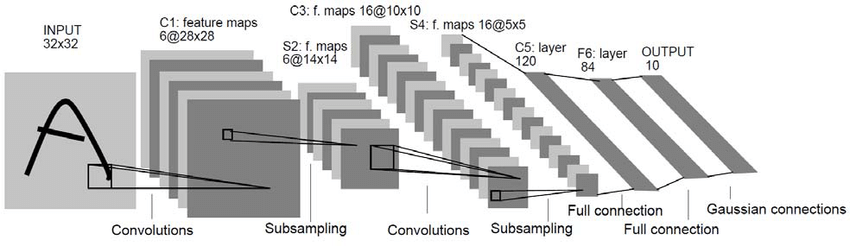

**AlexNet**
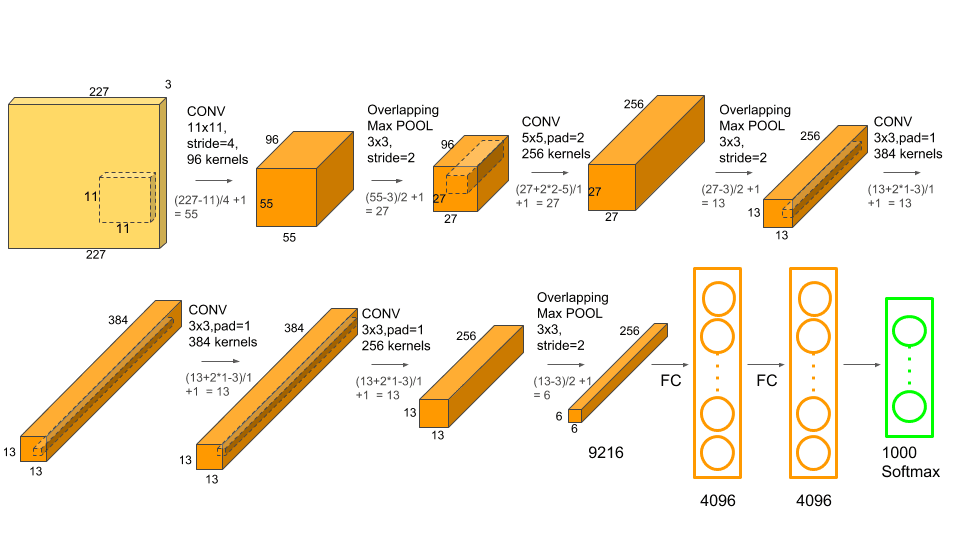

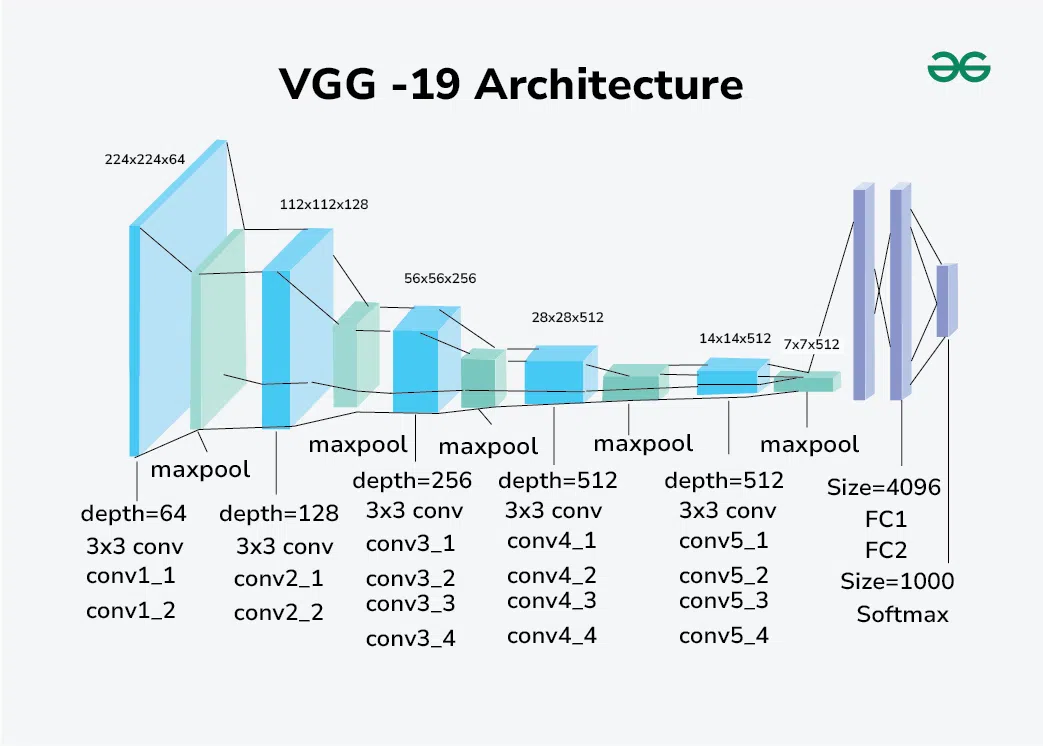

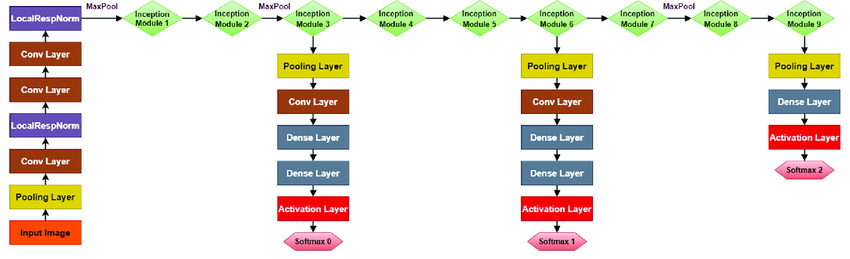

**ResNet Architecture**
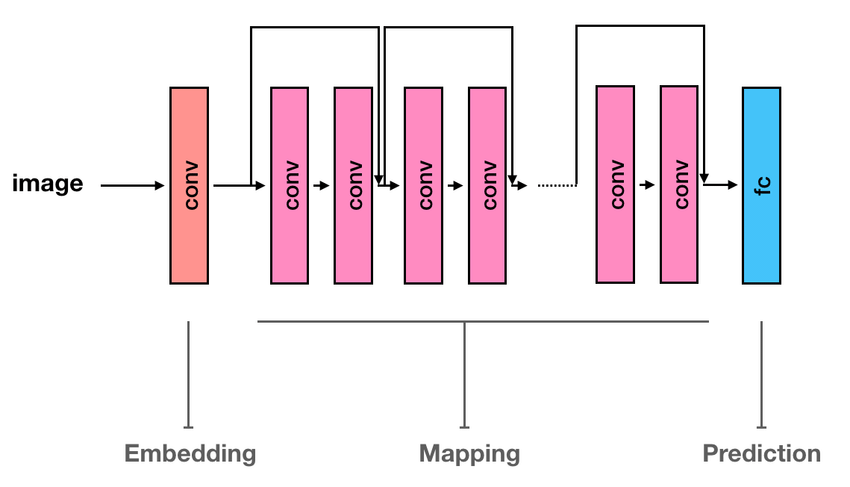

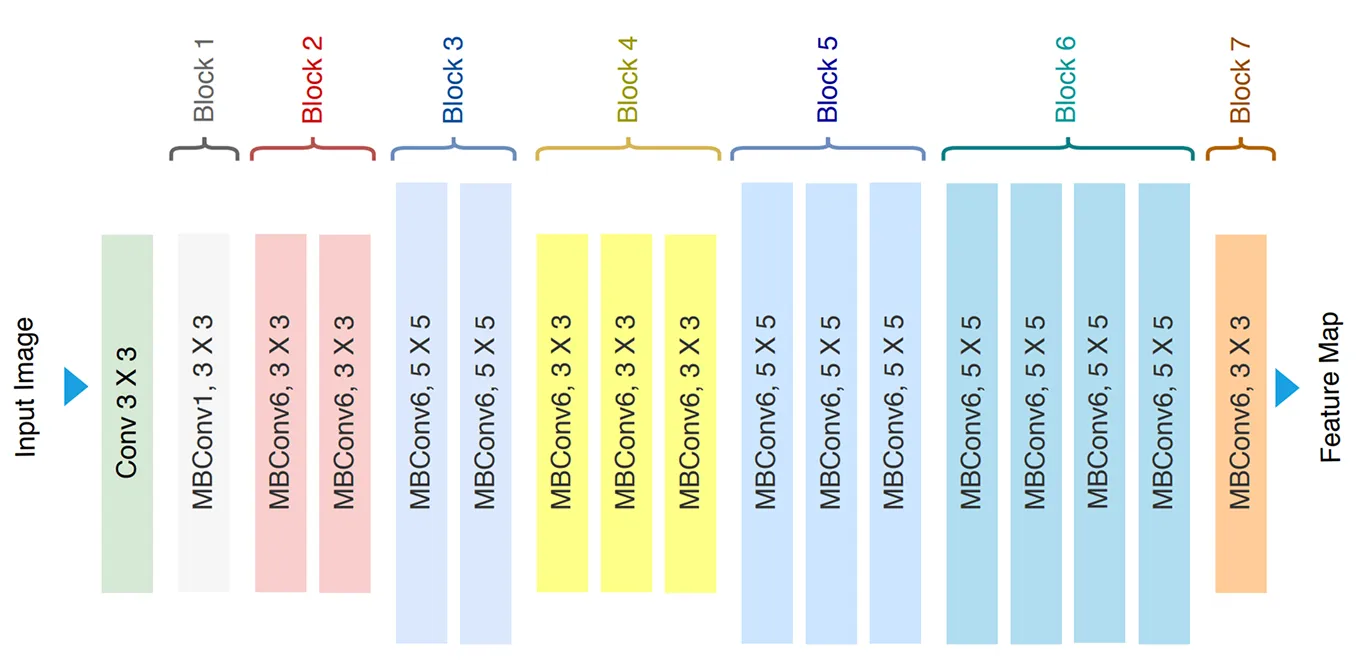

### Diagram: CNN stack (Conv → Pool → FC)

A typical flow: Input image → Conv layers (feature maps) → Pool (downsample) → Flatten → FC layers → Class scores.

![CNN Pipeline.png](<attachment:CNN Pipeline.png>)
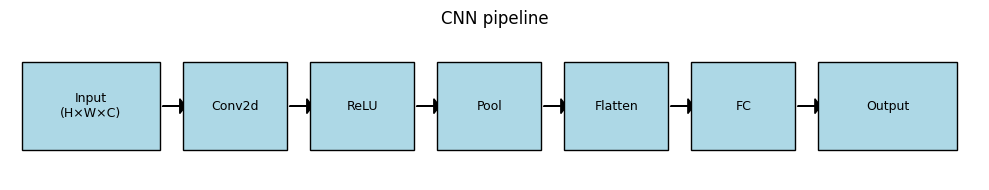